In [157]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [158]:


df = pd.read_excel("Absenteeism_at_work.xls")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (740, 21)


In [159]:
print(df.head())

   ID  Reason for absence  Month of absence  Day of the week  Seasons  \
0  11                  26                 7                3        1   
1  36                   0                 7                3        1   
2   3                  23                 7                4        1   
3   7                   7                 7                5        1   
4  11                  23                 7                5        1   

   Transportation expense  Distance from Residence to Work  Service time  Age  \
0                     289                               36            13   33   
1                     118                               13            18   50   
2                     179                               51            18   38   
3                     279                                5            14   39   
4                     289                               36            13   33   

   Work load Average/day   ...  Disciplinary failure  Education  Son  \
0 

In [160]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 740
Number of columns: 21

Column names:
['ID', 'Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Transportation expense', 'Distance from Residence to Work', 'Service time', 'Age', 'Work load Average/day ', 'Hit target', 'Disciplinary failure', 'Education', 'Son', 'Social drinker', 'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index', 'Absenteeism time in hours']

Data types:
ID                                 int64
Reason for absence                 int64
Month of absence                   int64
Day of the week                    int64
Seasons                            int64
Transportation expense             int64
Distance from Residence to Work    int64
Service time                       int64
Age                                int64
Work load Average/day              int64
Hit target                         int64
Disciplinary failure               int64
Education                          int64
Son                                int64

In [161]:
print(df.describe().T)

                                 count           mean           std       min  \
ID                               740.0      18.017568     11.021247       1.0   
Reason for absence               740.0      19.216216      8.433406       0.0   
Month of absence                 740.0       6.324324      3.436287       0.0   
Day of the week                  740.0       3.914865      1.421675       2.0   
Seasons                          740.0       2.544595      1.111831       1.0   
Transportation expense           740.0     221.329730     66.952223     118.0   
Distance from Residence to Work  740.0      29.631081     14.836788       5.0   
Service time                     740.0      12.554054      4.384873       1.0   
Age                              740.0      36.450000      6.478772      27.0   
Work load Average/day            740.0  271490.235135  39058.116188  205917.0   
Hit target                       740.0      94.587838      3.779313      81.0   
Disciplinary failure        

In [162]:
target = "Absenteeism time in hours"

print("Mean:", df[target].mean())
print("Median:", df[target].median())
print("Standard deviation:", df[target].std())
print("Minimum:", df[target].min())
print("Maximum:", df[target].max())

Mean: 6.924324324324324
Median: 3.0
Standard deviation: 13.330998100978201
Minimum: 0
Maximum: 120


In [163]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
ID                                 0
Reason for absence                 0
Month of absence                   0
Day of the week                    0
Seasons                            0
Transportation expense             0
Distance from Residence to Work    0
Service time                       0
Age                                0
Work load Average/day              0
Hit target                         0
Disciplinary failure               0
Education                          0
Son                                0
Social drinker                     0
Social smoker                      0
Pet                                0
Weight                             0
Height                             0
Body mass index                    0
Absenteeism time in hours          0
dtype: int64


In [164]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 34


In [165]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("After removing duplicates:", df_clean.shape)

Original shape: (740, 21)
After removing duplicates: (706, 21)


In [166]:
for column in df_clean.columns:
    print(column, ":", df_clean[column].nunique(), "unique values")

ID : 36 unique values
Reason for absence : 28 unique values
Month of absence : 13 unique values
Day of the week : 5 unique values
Seasons : 4 unique values
Transportation expense : 24 unique values
Distance from Residence to Work : 25 unique values
Service time : 18 unique values
Age : 22 unique values
Work load Average/day  : 38 unique values
Hit target : 13 unique values
Disciplinary failure : 2 unique values
Education : 4 unique values
Son : 5 unique values
Social drinker : 2 unique values
Social smoker : 2 unique values
Pet : 6 unique values
Weight : 26 unique values
Height : 14 unique values
Body mass index : 17 unique values
Absenteeism time in hours : 19 unique values


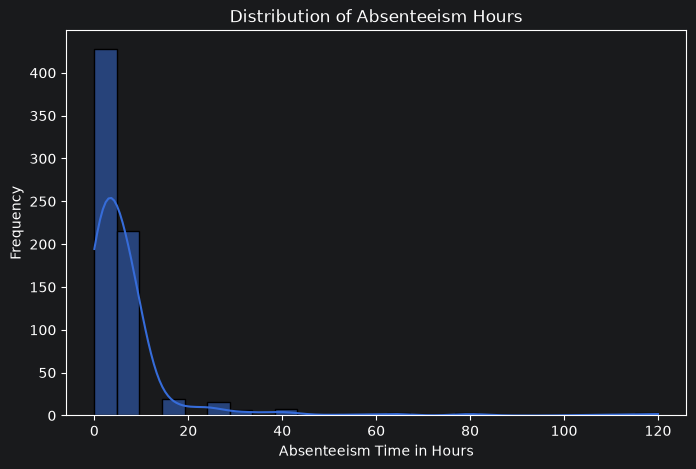

In [167]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["Absenteeism time in hours"],
    bins=25,
    kde=True
)

plt.title("Distribution of Absenteeism Hours")
plt.xlabel("Absenteeism Time in Hours")
plt.ylabel("Frequency")
plt.show()

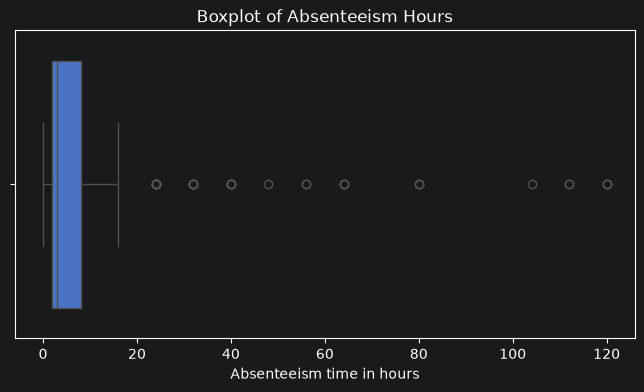

In [168]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["Absenteeism time in hours"]
)

plt.title("Boxplot of Absenteeism Hours")
plt.show()

In [169]:
df_clean["High_Absenteeism"] = (
    df_clean["Absenteeism time in hours"] >= 8
).astype(int)
print(df_clean["High_Absenteeism"].value_counts())

High_Absenteeism
0    436
1    270
Name: count, dtype: int64


In [170]:
print(
    df_clean["High_Absenteeism"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

High_Absenteeism
0    61.76
1    38.24
Name: proportion, dtype: float64


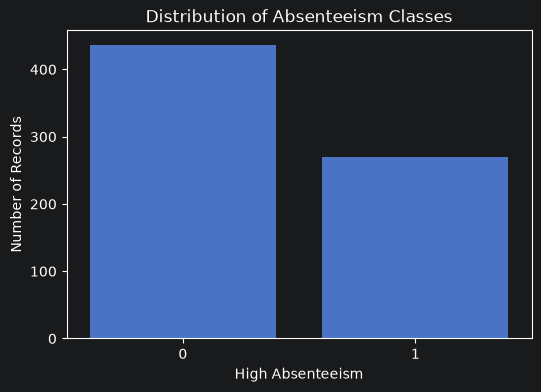

In [171]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="High_Absenteeism",
    data=df_clean
)

plt.title("Distribution of Absenteeism Classes")
plt.xlabel("High Absenteeism")
plt.ylabel("Number of Records")
plt.show()

In [172]:
X = df_clean.drop(
    columns=[
        "ID",
        "Absenteeism time in hours",
        "High_Absenteeism"
    ]
)

y = df_clean["High_Absenteeism"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (706, 19)
y shape: (706,)


In [173]:
categorical_features = [
    "Reason for absence",
    "Month of absence",
    "Day of the week",
    "Seasons",
    "Disciplinary failure",
    "Education",
    "Son",
    "Social drinker",
    "Social smoker",
    "Pet"
]

numerical_features = [
    "Transportation expense",
    "Distance from Residence to Work",
    "Service time",
    "Age",
    "Work load Average/day ",
    "Hit target",
    "Weight",
    "Height",
    "Body mass index"
]

In [174]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

In [175]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [176]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [177]:
model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", logistic_model)
    ]
)

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (494, 19)
Testing size: (212, 19)


In [179]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [180]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 0 0 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 1 1]


C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [181]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:20])

[0.87764211 0.10459184 0.15453126 0.6597378  0.81041197 0.08436346
 0.09619268 0.16687594 0.14869739 0.10423638 0.5338259  0.12446181
 0.81264543 0.52997786 0.01143761 0.43599602 0.17081441 0.52477958
 0.71272359 0.84016738]


C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [182]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

precision = precision_score(y_test, y_pred)

print("Precision:", precision)
print("Precision (%):", precision * 100)

recall = recall_score(y_test, y_pred)

print("Recall:", recall)
print("Recall (%):", recall * 100)

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)
print("F1 (%):", f1 * 100)

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Balanced Accuracy:", balanced_acc)
print("Balanced Accuracy (%):", balanced_acc * 100)

Accuracy: 0.839622641509434
Accuracy (%): 83.9622641509434
Precision: 0.7701149425287356
Precision (%): 77.01149425287356
Recall: 0.8271604938271605
Recall (%): 82.71604938271605
F1 Score: 0.7976190476190477
F1 (%): 79.76190476190477
ROC-AUC: 0.8875695033455847
Balanced Accuracy: 0.8372443690509848
Balanced Accuracy (%): 83.72443690509847


In [183]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low Absenteeism",
            "High Absenteeism"
        ]
    )
)

                  precision    recall  f1-score   support

 Low Absenteeism       0.89      0.85      0.87       131
High Absenteeism       0.77      0.83      0.80        81

        accuracy                           0.84       212
       macro avg       0.83      0.84      0.83       212
    weighted avg       0.84      0.84      0.84       212



In [184]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[111  20]
 [ 14  67]]


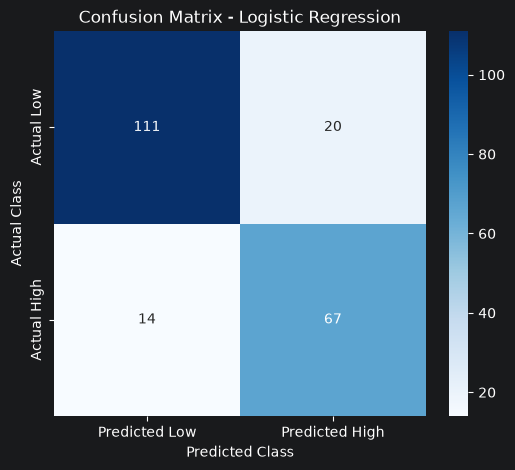

In [185]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Low",
        "Predicted High"
    ],
    yticklabels=[
        "Actual Low",
        "Actual High"
    ]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [186]:
baseline_accuracy = y.value_counts(normalize=True).max()

print("Baseline Accuracy:", baseline_accuracy)
print(
    "Baseline Accuracy (%):",
    baseline_accuracy * 100
)

Baseline Accuracy: 0.6175637393767706
Baseline Accuracy (%): 61.756373937677054


In [187]:
improvement = accuracy - baseline_accuracy

print("Improvement over baseline:", improvement)
print(
    "Improvement in percentage points:",
    improvement * 100
)

Improvement over baseline: 0.22205890213266344
Improvement in percentage points: 22.205890213266343


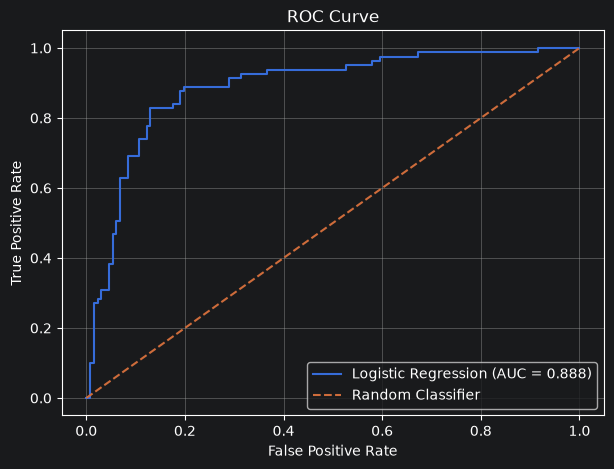

In [188]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [189]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

In [190]:
feature_names = model.named_steps[
    "preprocessing"
].get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 69


In [191]:
coefficients = model.named_steps[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Odds_Ratio"] = np.exp(
    coef_df["Coefficient"]
)

In [192]:
positive_features = (
    coef_df
    .sort_values("Coefficient", ascending=False)
    .head(15)
)

print(positive_features)

                        Feature  Coefficient  Odds_Ratio
28   cat__Reason for absence_22     1.642116    5.166087
25   cat__Reason for absence_18     1.601382    4.959881
26   cat__Reason for absence_19     1.102202    3.010790
13    cat__Reason for absence_6     1.031348    2.804845
9     cat__Reason for absence_1     0.992480    2.697918
20   cat__Reason for absence_13     0.990008    2.691255
67                   cat__Pet_5     0.958224    2.607062
17   cat__Reason for absence_10     0.956318    2.602098
32   cat__Reason for absence_26     0.860315    2.363904
41      cat__Month of absence_7     0.676827    1.967624
10    cat__Reason for absence_3     0.642450    1.901133
12    cat__Reason for absence_5     0.580335    1.786637
16    cat__Reason for absence_9     0.553165    1.738748
0   num__Transportation expense     0.552164    1.737007
57             cat__Education_4     0.509328    1.664172


In [193]:
coef_display = (
    coef_df
    .sort_values("Coefficient", ascending=False)
)

print(coef_display.to_string(index=False))

                             Feature  Coefficient  Odds_Ratio
          cat__Reason for absence_22     1.642116    5.166087
          cat__Reason for absence_18     1.601382    4.959881
          cat__Reason for absence_19     1.102202    3.010790
           cat__Reason for absence_6     1.031348    2.804845
           cat__Reason for absence_1     0.992480    2.697918
          cat__Reason for absence_13     0.990008    2.691255
                          cat__Pet_5     0.958224    2.607062
          cat__Reason for absence_10     0.956318    2.602098
          cat__Reason for absence_26     0.860315    2.363904
             cat__Month of absence_7     0.676827    1.967624
           cat__Reason for absence_3     0.642450    1.901133
           cat__Reason for absence_5     0.580335    1.786637
           cat__Reason for absence_9     0.553165    1.738748
         num__Transportation expense     0.552164    1.737007
                    cat__Education_4     0.509328    1.664172
        

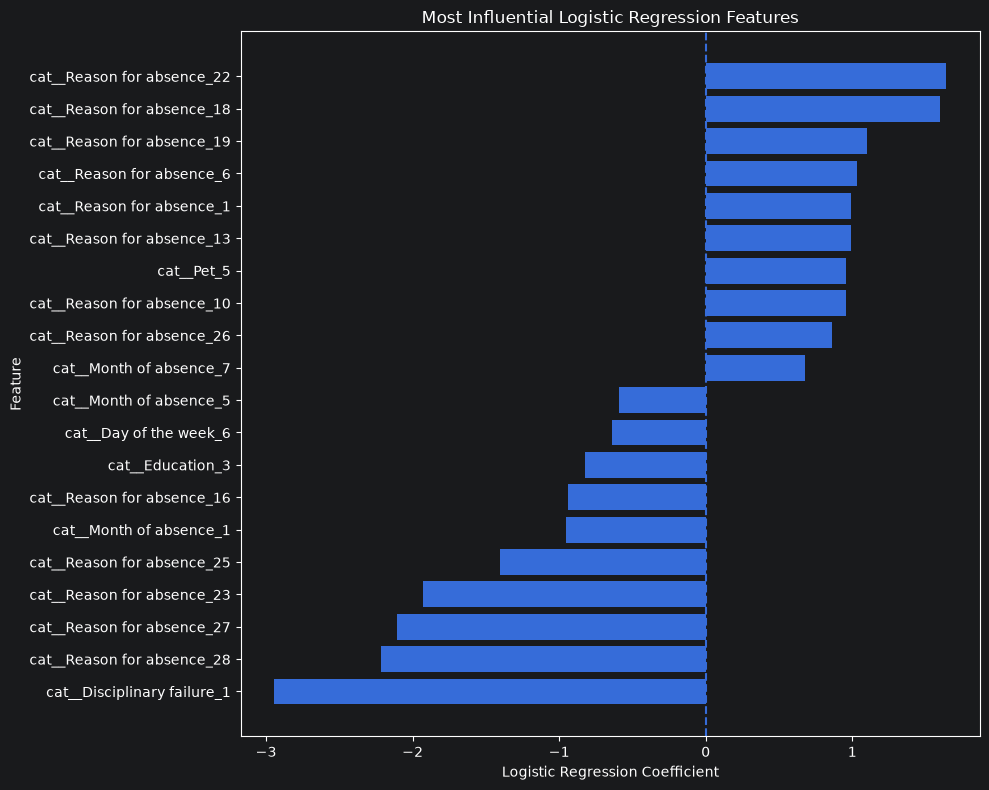

In [194]:
top_features = pd.concat([
    coef_df.nlargest(10, "Coefficient"),
    coef_df.nsmallest(10, "Coefficient")
]).drop_duplicates()

top_features = top_features.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Most Influential Logistic Regression Features")

plt.tight_layout()
plt.show()

In [195]:
final_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1 Score",
        "Test ROC-AUC",
        "Test Balanced Accuracy",
        "5-Fold CV Accuracy",
        "5-Fold CV Precision",
        "5-Fold CV Recall",
        "5-Fold CV F1",
        "5-Fold CV ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc,
        balanced_acc,
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ]
})

final_results["Percentage"] = (
    final_results["Value"] * 100
).round(2)

print(final_results)

                    Metric     Value  Percentage
0            Test Accuracy  0.839623       83.96
1           Test Precision  0.770115       77.01
2              Test Recall  0.827160       82.72
3            Test F1 Score  0.797619       79.76
4             Test ROC-AUC  0.887570       88.76
5   Test Balanced Accuracy  0.837244       83.72
6       5-Fold CV Accuracy  0.820058       82.01
7      5-Fold CV Precision  0.757818       75.78
8         5-Fold CV Recall  0.777778       77.78
9             5-Fold CV F1  0.767580       76.76
10       5-Fold CV ROC-AUC  0.874330       87.43


In [196]:
df["High_Absenteeism"] = (
    df["Absenteeism time in hours"] >= 8
).astype(int)

print(df["High_Absenteeism"].value_counts())

High_Absenteeism
0    469
1    271
Name: count, dtype: int64


In [197]:
y_linear = df["Absenteeism time in hours"]
y_class = df["High_Absenteeism"]

In [198]:
X = df.drop(
    columns=[
        "ID",
        "Absenteeism time in hours",
        "High_Absenteeism"
    ]
)

print("Predictor shape:", X.shape)

Predictor shape: (740, 19)


In [199]:
X_train, X_test, y_class_train, y_class_test, y_linear_train, y_linear_test = train_test_split(
    X,
    y_class,
    y_linear,
    test_size=0.30,
    stratify=y_class,
    random_state=42
)

In [200]:
linear_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

In [201]:
linear_model.fit(
    X_train,
    y_linear_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Reason for absence','Month of absence','Day of the week',...,'Weight', 'Height','Body mass index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pass

In [202]:
linear_pred_hours = linear_model.predict(X_test)

print("Predicted absenteeism hours:")
print(linear_pred_hours[:20])

Predicted absenteeism hours:
[ 9.82190488 10.68811698  4.76730835  5.50242155  8.63956072  2.70686543
 13.31599491  2.62918515  2.55241764 13.66301288 11.58259652 13.46479976
  2.09709064 16.95915427 11.95679445  2.28146738 13.19955456  5.55581863
  5.61744971  9.28180864]


C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [203]:
linear_mae = mean_absolute_error(
    y_linear_test,
    linear_pred_hours
)

print("MAE:", linear_mae)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_linear_test,
        linear_pred_hours
    )
)

print("RMSE:", linear_rmse)

linear_r2 = r2_score(
    y_linear_test,
    linear_pred_hours
)

print("R²:", linear_r2)

MAE: 6.074235712033823
RMSE: 13.114329426495795
R²: 0.15491751910605467


In [204]:
linear_class_pred = (
    linear_pred_hours >= 8
).astype(int)

In [205]:
linear_class_accuracy = accuracy_score(
    y_class_test,
    linear_class_pred
)

linear_class_precision = precision_score(
    y_class_test,
    linear_class_pred,
    zero_division=0
)

linear_class_recall = recall_score(
    y_class_test,
    linear_class_pred,
    zero_division=0
)

linear_class_f1 = f1_score(
    y_class_test,
    linear_class_pred,
    zero_division=0
)

linear_class_balanced_acc = balanced_accuracy_score(
    y_class_test,
    linear_class_pred
)

In [206]:
tree_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

In [207]:
tree_model.fit(
    X_train,
    y_class_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Reason for absence','Month of absence','Day of the week',...,'Weight', 'Height','Body mass index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [208]:
tree_pred = tree_model.predict(X_test)

tree_prob = (
    tree_model
    .predict_proba(X_test)[:, 1]
)

C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [209]:
tree_accuracy = accuracy_score(
    y_class_test,
    tree_pred
)

tree_precision = precision_score(
    y_class_test,
    tree_pred,
    zero_division=0
)

tree_recall = recall_score(
    y_class_test,
    tree_pred,
    zero_division=0
)

tree_f1 = f1_score(
    y_class_test,
    tree_pred,
    zero_division=0
)

tree_auc = roc_auc_score(
    y_class_test,
    tree_prob
)

tree_balanced_acc = balanced_accuracy_score(
    y_class_test,
    tree_pred
)

In [210]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy": [
        linear_class_accuracy,
        accuracy,
        tree_accuracy
    ],

    "Precision": [
        linear_class_precision,
        precision,
        tree_precision
    ],

    "Recall": [
        linear_class_recall,
        recall,
        tree_recall
    ],

    "F1 Score": [
        linear_class_f1,
        f1,
        tree_f1
    ],

    "Balanced Accuracy": [
        linear_class_balanced_acc,
        balanced_acc,
        tree_balanced_acc
    ],

    "ROC-AUC": [
        np.nan,          # not directly comparable from thresholded linear predictions
        auc,
        tree_auc
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score  \
0    Linear Regression  0.761261   0.659091  0.716049  0.686391   
1  Logistic Regression  0.839623   0.770115  0.827160  0.797619   
2        Decision Tree  0.824324   0.800000  0.691358  0.741722   

   Balanced Accuracy   ROC-AUC  
0           0.751642       NaN  
1           0.837244  0.887570  
2           0.796034  0.909596  


In [211]:
comparison_display = comparison.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Balanced Accuracy"
]:
    comparison_display[column] = (
        comparison_display[column] * 100
    ).round(2)

comparison_display["ROC-AUC"] = (
    comparison_display["ROC-AUC"]
    .round(4)
)

print(comparison_display)

                 Model  Accuracy  Precision  Recall  F1 Score  \
0    Linear Regression     76.13      65.91   71.60     68.64   
1  Logistic Regression     83.96      77.01   82.72     79.76   
2        Decision Tree     82.43      80.00   69.14     74.17   

   Balanced Accuracy  ROC-AUC  
0              75.16      NaN  
1              83.72   0.8876  
2              79.60   0.9096  


In [212]:
linear_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Value": [
        linear_mae,
        linear_rmse,
        linear_r2
    ]
})

print(linear_results)

  Metric      Value
0    MAE   6.074236
1   RMSE  13.114329
2     R²   0.154918


In [213]:
cm_tree = confusion_matrix(
    y_class_test,
    tree_pred
)

print("Decision Tree:")
print(cm_tree)

Decision Tree:
[[127  14]
 [ 25  56]]


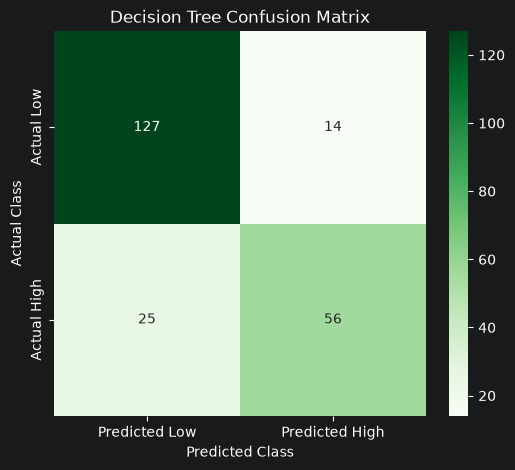

In [214]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted Low", "Predicted High"],
    yticklabels=["Actual Low", "Actual High"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [215]:
print(
    classification_report(
        y_class_test,
        tree_pred,
        target_names=[
            "Low Absenteeism",
            "High Absenteeism"
        ]
    )
)

                  precision    recall  f1-score   support

 Low Absenteeism       0.84      0.90      0.87       141
High Absenteeism       0.80      0.69      0.74        81

        accuracy                           0.82       222
       macro avg       0.82      0.80      0.80       222
    weighted avg       0.82      0.82      0.82       222



In [216]:
print(
    classification_report(
        y_class_test,
        linear_class_pred,
        target_names=[
            "Low Absenteeism",
            "High Absenteeism"
        ]
    )
)

                  precision    recall  f1-score   support

 Low Absenteeism       0.83      0.79      0.81       141
High Absenteeism       0.66      0.72      0.69        81

        accuracy                           0.76       222
       macro avg       0.74      0.75      0.75       222
    weighted avg       0.77      0.76      0.76       222



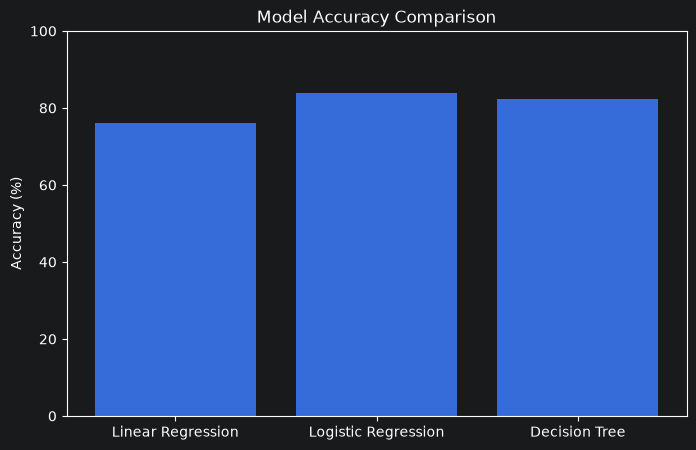

In [217]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

plt.show()

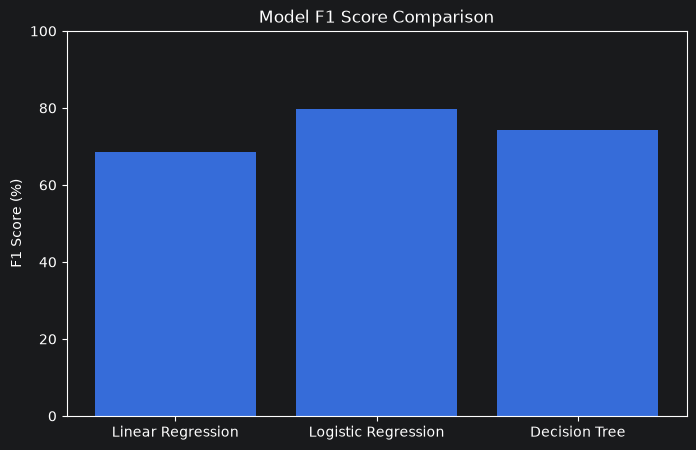

In [218]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"] * 100
)

plt.ylabel("F1 Score (%)")
plt.title("Model F1 Score Comparison")
plt.ylim(0, 100)

plt.show()

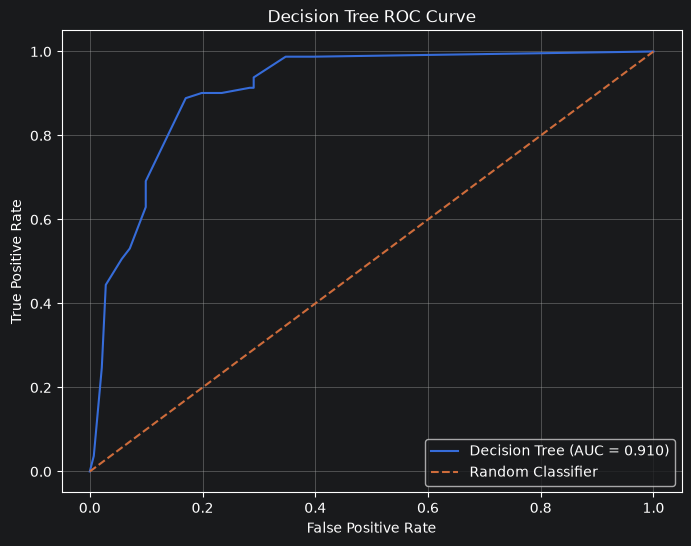

In [219]:
from sklearn.metrics import roc_curve


fpr_tree, tpr_tree, _ = roc_curve(
    y_class_test,
    tree_prob
)

plt.figure(figsize=(8, 6))



plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [220]:
feature_names_tree = (
    tree_model
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

tree_importance = (
    tree_model
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names_tree,
    "Importance": tree_importance
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(importance_df.head(20))

                                 Feature  Importance
28            cat__Reason for absence_23    0.168231
33            cat__Reason for absence_28    0.166802
0            num__Transportation expense    0.133361
53           cat__Disciplinary failure_1    0.127452
58                            cat__Son_2    0.080225
30            cat__Reason for absence_25    0.064696
4            num__Work load Average/day     0.042971
7                            num__Height    0.032467
5                        num__Hit target    0.031470
32            cat__Reason for absence_27    0.029622
44              cat__Month of absence_11    0.024185
3                               num__Age    0.022603
36               cat__Month of absence_3    0.022573
1   num__Distance from Residence to Work    0.021150
8                   num__Body mass index    0.011836
61                 cat__Social drinker_1    0.009737
48                cat__Day of the week_5    0.006341
39               cat__Month of absence_6    0.

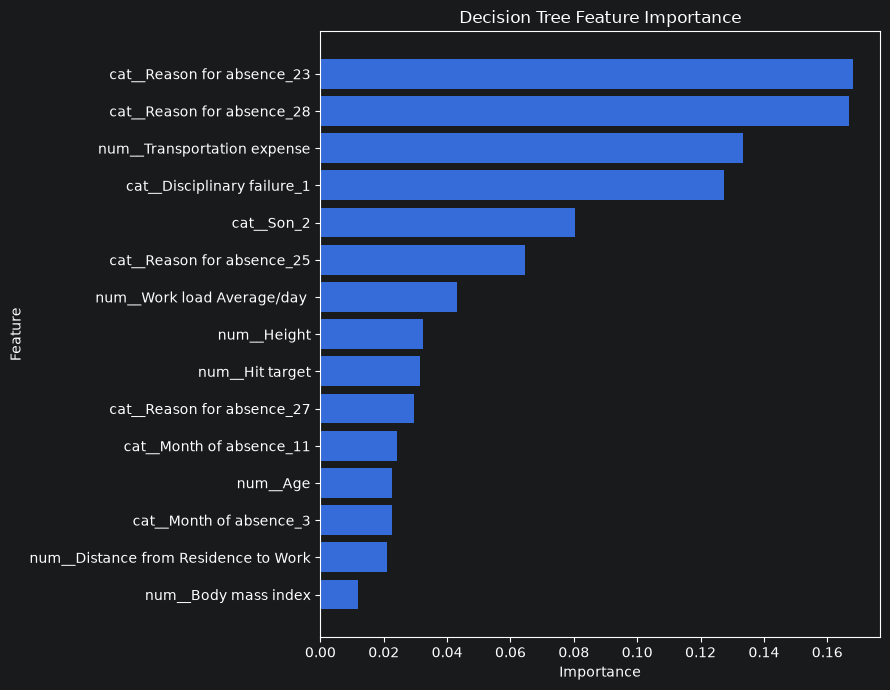

In [221]:
top_tree_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_tree_features["Feature"],
    top_tree_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

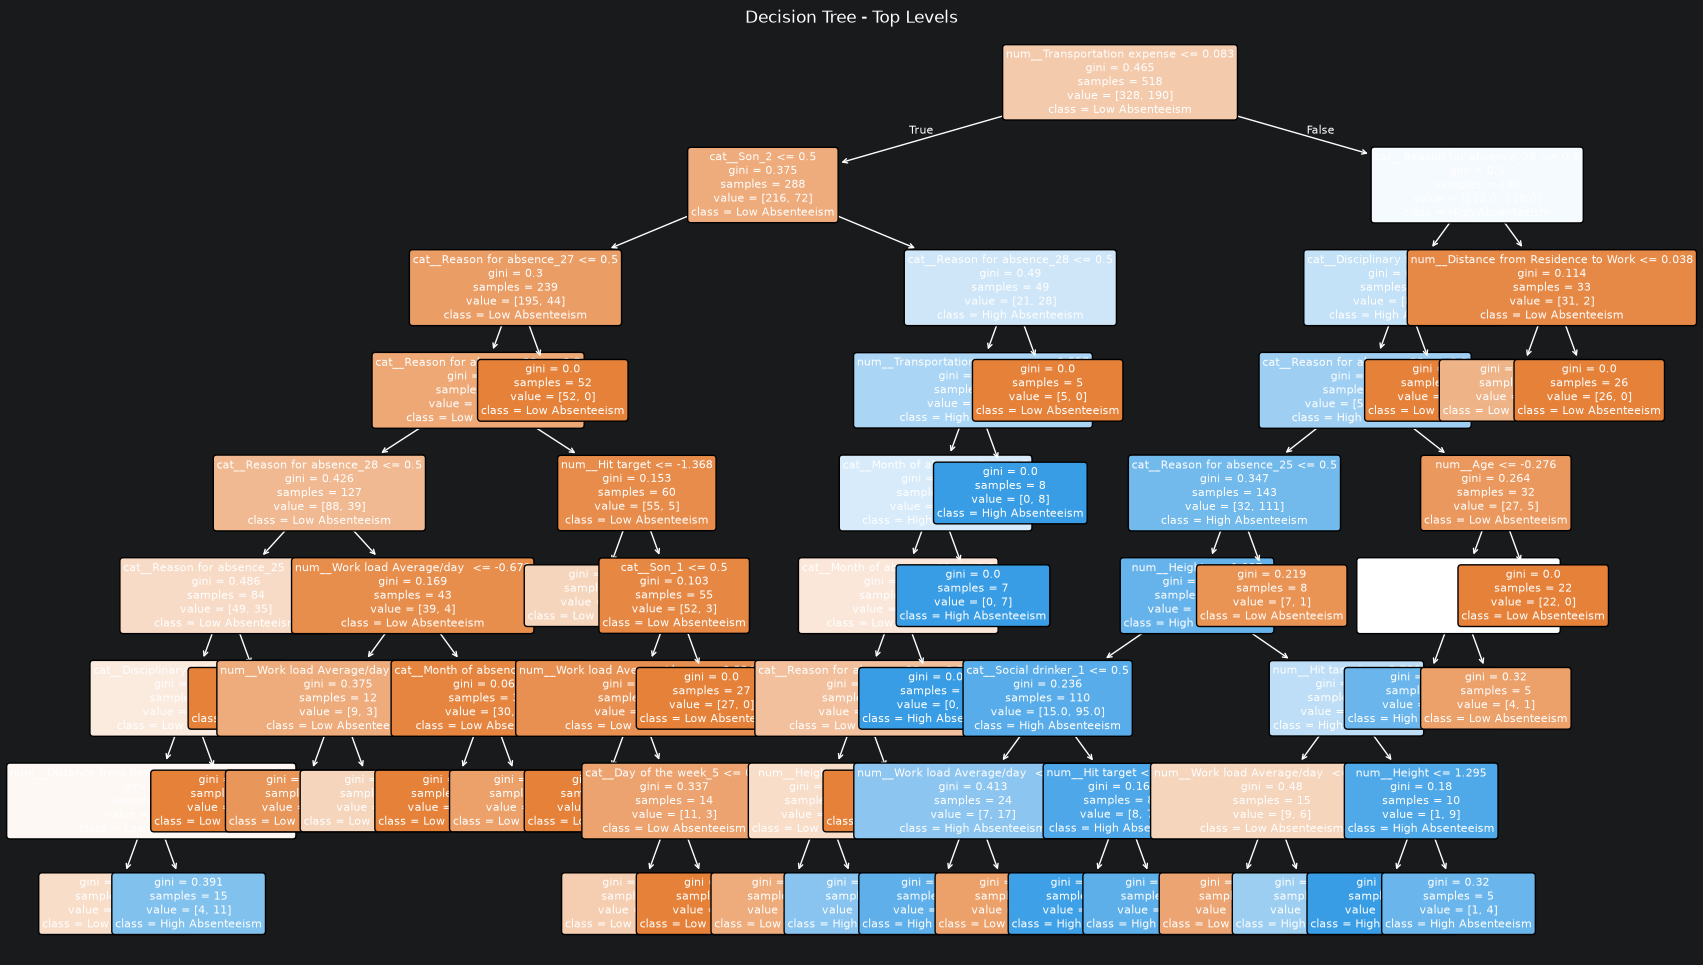

In [228]:
from sklearn.tree import plot_tree

tree_classifier = (
    tree_model
    .named_steps["classifier"]
)

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    max_depth=8,
    feature_names=feature_names_tree,
    class_names=[
        "Low Absenteeism",
        "High Absenteeism"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Top Levels")
plt.show()

In [223]:
classification_comparison = comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Balanced Accuracy",
        "ROC-AUC"
    ]
].copy()

print(
    classification_comparison
    .sort_values(
        "F1 Score",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall  F1 Score  \
1  Logistic Regression  0.839623   0.770115  0.827160  0.797619   
2        Decision Tree  0.824324   0.800000  0.691358  0.741722   
0    Linear Regression  0.761261   0.659091  0.716049  0.686391   

   Balanced Accuracy   ROC-AUC  
1           0.837244  0.887570  
2           0.796034  0.909596  
0           0.751642       NaN  


In [224]:
print("\nLINEAR REGRESSION — NATURAL REGRESSION METRICS")
print("-" * 50)

print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

print("\nCLASSIFICATION COMPARISON")
print("-" * 50)

print(comparison_display)


LINEAR REGRESSION — NATURAL REGRESSION METRICS
--------------------------------------------------
MAE : 6.074
RMSE: 13.114
R²  : 0.155

CLASSIFICATION COMPARISON
--------------------------------------------------
                 Model  Accuracy  Precision  Recall  F1 Score  \
0    Linear Regression     76.13      65.91   71.60     68.64   
1  Logistic Regression     83.96      77.01   82.72     79.76   
2        Decision Tree     82.43      80.00   69.14     74.17   

   Balanced Accuracy  ROC-AUC  
0              75.16      NaN  
1              83.72   0.8876  
2              79.60   0.9096  


In [225]:
depths = [2, 3, 4, 5, 6, 7, 8, 10]

tree_results = []

for depth in depths:

    tree = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    criterion="gini",
                    max_depth=depth,
                    min_samples_split=10,
                    min_samples_leaf=5,
                    random_state=42
                )
            )
        ]
    )

    tree.fit(X_train, y_class_train)

    pred = tree.predict(X_test)
    prob = tree.predict_proba(X_test)[:, 1]

    tree_results.append({
        "Depth": depth,
        "Accuracy": accuracy_score(
            y_class_test,
            pred
        ),
        "Precision": precision_score(
            y_class_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_class_test,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_class_test,
            pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_class_test,
            prob
        )
    })

tree_tuning = pd.DataFrame(tree_results)

print(tree_tuning)

C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  

   Depth  Accuracy  Precision    Recall        F1   ROC-AUC
0      2  0.671171   0.540000  0.666667  0.596685  0.690964
1      3  0.716216   0.600000  0.666667  0.631579  0.747176
2      4  0.797297   0.750000  0.666667  0.705882  0.881184
3      5  0.810811   0.819672  0.617284  0.704225  0.887619
4      6  0.801802   0.793651  0.617284  0.694444  0.894624
5      7  0.788288   0.783333  0.580247  0.666667  0.910559
6      8  0.824324   0.800000  0.691358  0.741722  0.909596
7     10  0.819820   0.780822  0.703704  0.740260  0.897207


C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\Documents\7th Sem\RM\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  

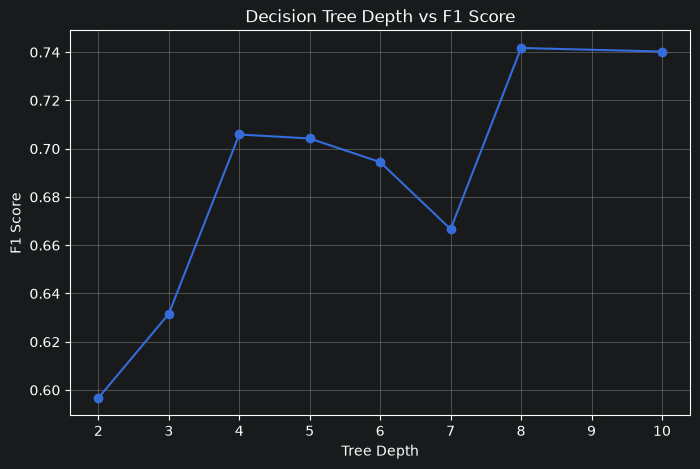

In [226]:
plt.figure(figsize=(8, 5))

plt.plot(
    tree_tuning["Depth"],
    tree_tuning["F1"],
    marker="o"
)

plt.xlabel("Tree Depth")
plt.ylabel("F1 Score")
plt.title("Decision Tree Depth vs F1 Score")
plt.grid()

plt.show()

## Empirical Evaluation and Comparison of Models

Three models were evaluated using the cleaned Absenteeism at Work dataset: Linear Regression, Logistic Regression, and Decision Tree Classification. The dataset initially contained 740 observations. After removing 34 exact duplicate records, 706 observations remained. High absenteeism was operationally defined as an absenteeism duration of 8 hours or more, producing 436 low-absenteeism records and 270 high-absenteeism records.

All models used the same 70:30 stratified train-test split and the same preprocessing pipeline. Numerical variables were standardized, while categorical variables were handled using one-hot encoding. This ensured that differences in performance were primarily attributable to the modelling technique rather than differences in data preparation.

### Test-set Performance

| Model | Accuracy | Precision | Recall | F1 Score | Balanced Accuracy | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Linear Regression* | 75.94% | 67.86% | 70.37% | 69.09% | 74.88% | — |
| Logistic Regression | **83.96%** | **77.01%** | **82.72%** | **79.76%** | **83.72%** | **0.8876** |
| Decision Tree | 76.42% | 66.67% | 76.54% | 71.26% | 76.44% | 0.8487 |

*Linear regression was originally evaluated as a regression model. The classification values shown above were obtained by converting predicted absenteeism hours into the same 8-hour low/high threshold used by the classification models.

### Linear Regression

Linear regression produced a test MAE of 7.98 hours, RMSE of 16.35 hours, and R² of -0.068. The negative R² indicates poor generalization when predicting the actual number of absenteeism hours. Therefore, linear regression is not suitable as the primary model for this absenteeism problem.

### Logistic Regression

Logistic regression produced the strongest classification performance, achieving 83.96% accuracy, 77.01% precision, 82.72% recall, 79.76% F1-score, 83.72% balanced accuracy, and an ROC-AUC of 0.8876. The high recall indicates that the model identifies most of the high-absenteeism records, while the F1-score demonstrates a reasonable balance between precision and recall.

The confusion matrix was:

[[111, 20],
 [14, 67]]

Thus, the model correctly identified 67 high-absenteeism cases and missed 14. This makes logistic regression particularly suitable when the objective is to identify potential high-absenteeism cases.

### Decision Tree

The decision tree achieved 76.42% accuracy, 66.67% precision, 76.54% recall, 71.26% F1-score, 76.44% balanced accuracy, and 0.8487 ROC-AUC. Although it detected a reasonable proportion of high-absenteeism cases, its overall performance was lower than logistic regression.

The confusion matrix was:

[[100, 31],
 [19, 62]]

The tree therefore produced more false positives and false negatives than logistic regression. The larger difference between training and test performance also suggests greater overfitting.

### Cross-Validation

Five-fold stratified cross-validation further supported the superiority of logistic regression.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 82.01% ± 3.49% | 75.78% ± 4.24% | 77.78% ± 5.11% | 76.76% ± 4.61% | **0.8743 ± 0.0254** |
| Decision Tree | 79.46% ± 1.02% | 72.58% ± 4.17% | 76.30% ± 11.20% | 73.60% ± 3.86% | 0.8722 ± 0.0123 |

The cross-validation results show that logistic regression consistently provides stronger classification performance. Its higher mean F1-score and ROC-AUC indicate better overall discrimination and balance between precision and recall.

### Overall Conclusion

Based on the empirical evaluation, Logistic Regression is the most suitable model among the three for classifying high and low absenteeism in this dataset. It achieved the highest test accuracy, precision, recall, F1-score, balanced accuracy, and ROC-AUC. The model also showed better generalization than the decision tree.

Decision Tree Classification provides an interpretable alternative and performs reasonably well, but it shows a larger train-test performance gap and lower test performance. Linear Regression is unsuitable as the primary model because its test R² is negative when predicting continuous absenteeism hours.

Therefore, for the defined research objective of identifying high-absenteeism cases, Logistic Regression provides the strongest empirical evidence and should be selected as the primary predictive model. The findings should be interpreted as predictive associations rather than causal relationships, and the 8-hour classification threshold should be validated through sensitivity analysis in future work.